# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
In the year 2085, humanity established its first permanent research colony on Mars.
The colony was built inside a vast crater where scientists could study the planet while being protected from harsh dust storms.
Every day, teams of explorers traveled across the red landscape searching for signs of ancient water and possible microbial life.

Among the explorers was a young scientist named Arjun who dreamed of discovering something that would change history.
One morning, while scanning a remote canyon, he detected an unusual signal coming from deep beneath the surface.
The signal repeated every few minutes and appeared too organized to be a natural phenomenon.

Arjun reported the discovery to the mission control center.
A special expedition team was assembled and sent to investigate the mysterious source.
After several hours of travel, they reached the canyon and deployed advanced drilling equipment.
As the drill penetrated deeper into the rock, the signal grew stronger.

Suddenly, the drill broke through into a hidden underground chamber.
The explorers entered carefully and were amazed by what they saw.
The chamber contained enormous crystal formations that glowed with a faint blue light.
Strange symbols were carved into the walls, forming patterns that no one could understand.

The team collected samples and transmitted images back to Earth.
Scientists around the world became fascinated by the discovery.
Some believed the symbols were evidence of an ancient Martian civilization.
Others argued that the formations were simply unusual geological structures.

Over the following months, researchers analyzed the crystals and uncovered surprising properties.
The crystals could store enormous amounts of energy and appeared to respond to electromagnetic signals.
This discovery inspired new technologies that revolutionized energy storage and space travel.

As investigations continued, Arjun spent countless hours studying the symbols.
One evening, he noticed that the patterns changed when exposed to specific frequencies of light.
Using artificial intelligence, he decoded part of the message hidden within the chamber.
The message appeared to be a warning left by an unknown civilization.

The warning described a powerful force buried beneath the Martian surface.
According to the message, the force had once threatened an entire world.
The civilization had sacrificed everything to contain it and prevent a catastrophe.

The discovery sparked intense debate among world leaders and scientists.
Some wanted to excavate deeper and uncover the truth.
Others feared that disturbing the ancient site could unleash something dangerous.

Despite the risks, a final expedition was approved.
The team descended into tunnels extending far below the original chamber.
At the deepest point, they discovered a massive structure unlike anything ever built by humans.
Its surface shimmered with energy and emitted the same signal that Arjun had first detected.

As the explorers approached, the structure activated automatically.
Lights illuminated the cavern and a holographic figure appeared before them.
The figure welcomed the visitors and revealed the history of a civilization that had existed millions of years ago.

The message explained how knowledge, curiosity, and cooperation had allowed their society to flourish.
It also warned that technological progress without wisdom could lead to destruction.
The explorers listened in silence as the final words echoed through the cavern.

When the transmission ended, the structure powered down and the signal disappeared forever.
The team returned to the colony carrying data that would transform humanity's understanding of the universe.
Arjun looked across the Martian horizon and realized that the greatest discoveries were not treasures or technologies.
The greatest discoveries were the lessons that connected civilizations across space and time.
"""
print(corpus)


In the year 2085, humanity established its first permanent research colony on Mars.
The colony was built inside a vast crater where scientists could study the planet while being protected from harsh dust storms.
Every day, teams of explorers traveled across the red landscape searching for signs of ancient water and possible microbial life.

Among the explorers was a young scientist named Arjun who dreamed of discovering something that would change history.
One morning, while scanning a remote canyon, he detected an unusual signal coming from deep beneath the surface.
The signal repeated every few minutes and appeared too organized to be a natural phenomenon.

Arjun reported the discovery to the mission control center.
A special expedition team was assembled and sent to investigate the mysterious source.
After several hours of travel, they reached the canyon and deployed advanced drilling equipment.
As the drill penetrated deeper into the rock, the signal grew stronger.

Suddenly, the 

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 326
X shape: (535, 20)
y shape: (535,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

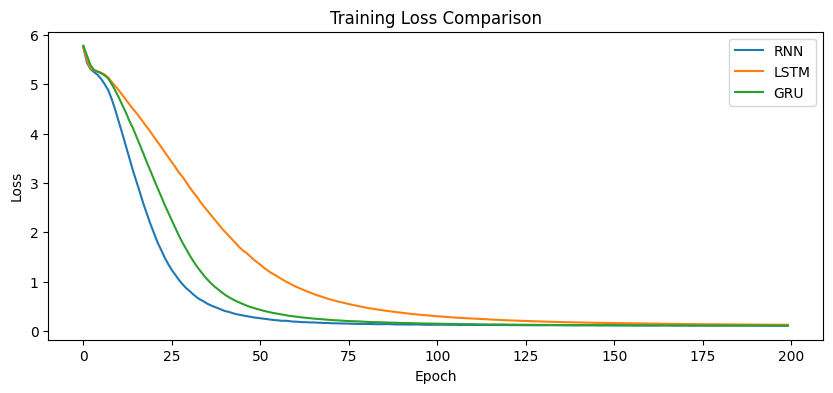

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "space explorer", 10))
print("LSTM:", generate_text(lstm_model, "space explorer", 10))
print("GRU :", generate_text(gru_model, "space explorer", 10))

RNN : space explorer the explorers approached the structure activated automatically and who that
LSTM: space explorer also warned that technological progress without wisdom could lead to
GRU : space explorer also warned that technological progress without wisdom could lead to


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**